In [54]:
%load_ext autoreload
%autoreload 2
from NLSE import SingleRing
import numpy as np
import matplotlib.pyplot as plt

c = 299792458

wl_center = 1560e-9
omega_0 = 2 * np.pi * c / wl_center

neff = c / ( 630e-6 * 200e9 )

alpha = 0.0018
theta = 0.0005
alpha_int = 2 * alpha - theta

simulation = SingleRing(
    neff=neff, 
    FSR=200e9,
    coupling_ring_bus=0.0005,
    coupling_ring_drop=0,
    gamma=0.9,
    alpha_int=alpha_int,
    beta_2=-202e-27,
    omega_0=omega_0,
    n_small_time=512
)

detuning = 4.5 * simulation.alpha
intensity_in = simulation.S_2_Iin(np.sqrt(8.7))

A_in = -1j * np.sqrt(intensity_in) * np.ones(simulation.time.shape)
A_init = simulation.make_seed(detuning, intensity_in)
# A_init = 1j * np.sqrt(simulation.alpha / (simulation.gamma * simulation.cavity_length)) \
        # * np.sqrt(2 * 4.5) / np.cosh(np.sqrt(4.5) * simulation.time_normalized)

run_sim = simulation.get_ikeda_map()
A_main, A_out, A_drop = run_sim(A_init, A_in, detuning=detuning, nrt=10 / simulation.alpha, n_per_step=5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
1 / simulation.alpha
simulation.alpha, simulation.alpha_int, simulation.alpha_int / simulation.cavity_length, simulation.cavity_length

(0.0018, 0.0031, 4.92063492063492, 0.00063)

In [56]:
simulation.time_normalized.shape

(512,)

In [57]:
intensity_in, neff

(Array(0.17897142, dtype=float32), 2.3793052222222224)

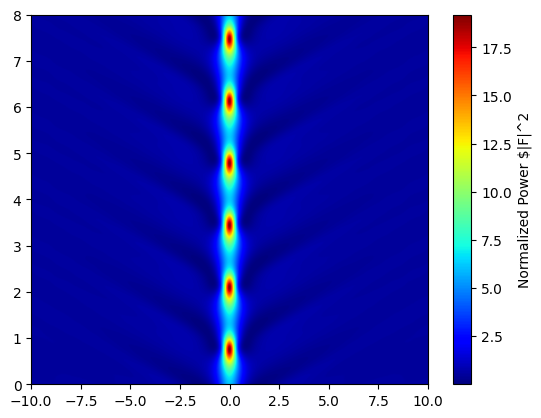

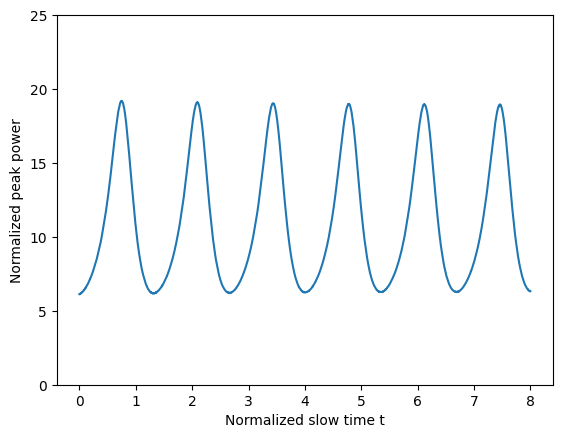

In [78]:
start = round( 1.54 / simulation.alpha )
# start = 0
end = round(9.54 / simulation.alpha)

F = np.sqrt(simulation.gamma * simulation.cavity_length / simulation.alpha) * A_main[start:end]
plt.imshow(np.abs(F[::-1]) ** 2, extent=[np.min(simulation.time_normalized), np.max(simulation.time_normalized), 0, 8], aspect='auto', cmap='jet')
plt.xlim(-10, 10)
plt.colorbar(label='Normalized Power $|F|^2')
plt.show()


F_max = np.amax(np.abs(F) ** 2, axis=1)
slow_time = 8 * np.arange(len(F_max)) / len(F_max)
plt.plot(slow_time, F_max)
plt.ylim(0, 25)
plt.xlabel('Normalized slow time t')
plt.ylabel('Normalized peak power')
plt.show()

In [89]:
intensity_in = 8.7 / ( simulation.gamma * simulation.cavity_length * simulation.coupling_ring_bus / alpha ** 3 )
intensity_in

0.17897142857142853

In [9]:
simulation.S_2_Iin(np.sqrt(8.7))

Array(0.17897142, dtype=float32)

In [11]:
tau_normalized = simulation.time * np.sqrt( 2 * alpha / ( abs(simulation.beta_2) * simulation.cavity_length ) )

seed = np.sqrt(alpha / (simulation.gamma * simulation.cavity_length)) * np.sqrt(2 * 4.5) / np.cosh(np.sqrt(4.5) * tau_normalized)
seed2 = np.sqrt(2 * 4.5 * alpha) / np.sqrt(simulation.gamma * simulation.cavity_length) * 1 / np.cosh(np.sqrt(2 * 4.5 * alpha / (np.abs(simulation.beta_2) * simulation.cavity_length)) * simulation.time)

In [19]:
4.5 * simulation.alpha

0.0081

(-10000000000000.0, 10000000000000.0)

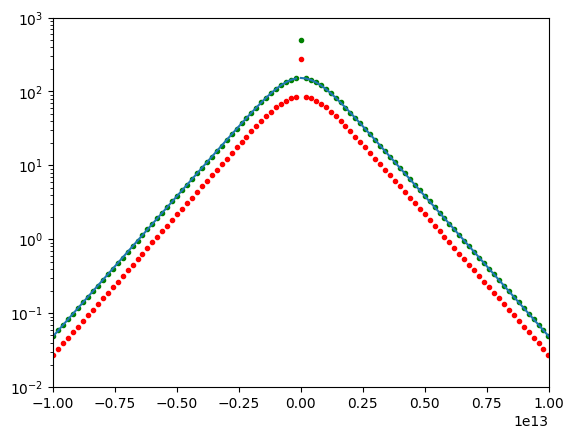

In [21]:
freq = np.fft.fftfreq(len(simulation.time), np.diff(simulation.time)[0])



plt.plot(freq,np.abs(np.fft.fft(
    simulation.make_seed(
        4.5 * simulation.alpha, 
        simulation.S_2_Iin(np.sqrt(8.7))
    )
)), 'g.')

plt.plot(freq,np.abs(np.fft.fft(simulation.make_seed_normalized(4.5, np.sqrt(8.7)))), 'r.')
plt.plot(freq,np.abs(np.fft.fft(seed)))
plt.yscale('log')
plt.ylim(1e-2, 1000)
plt.xlim(-1e13, 1e13)

In [6]:
F_over_ain = np.sqrt(simulation.coupling_ring_bus * simulation.gamma * simulation.cavity_length / alpha ** 3)
np.exp(1j * np.arccos(np.sqrt(8) * 4.5 / (np.pi * F)))

NameError: name 'F' is not defined

In [ ]:
simulation.S_over_ain

In [ ]:
_delta = 4.5
S = np.sqrt(8.7)
simulation.make_seed_normalized(4.5, np.sqrt(8.7))

In [ ]:
np.arccos(np.sqrt(8 * 4.5)/(np.pi * np.sqrt(8.7)))

In [ ]:
1 / jnp.cosh(jnp.sqrt(detuning) * self.time_normalized)